In [1]:
import json
from typing import Sequence

import agama
import gc_utils
import h5py
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import utilities as ut
from scipy.signal import savgol_filter

In [2]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

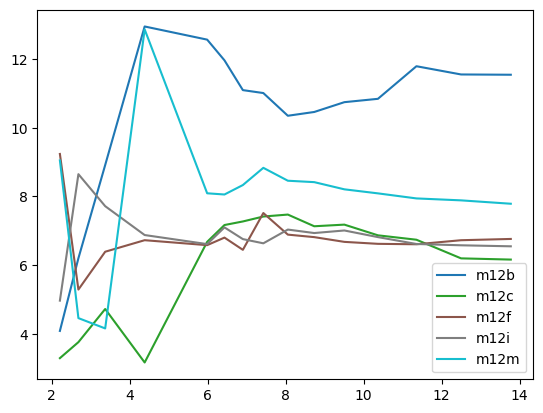

In [3]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
snap_lim_lst = [46, 46, 46, 46, 102]
# sim_lst = ["m12i"]
# snap_lim_lst = [46

snap_min = 120
snap_max = 590

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

sim_dict = {sim: {} for sim in sim_lst}

group_id = 0

for j, sim in enumerate(sim_lst):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    snap_lim = snap_lim_lst[j]
    # time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].values
    time_lst = pub_snaps[(pub_snaps["index"] >= snap_min) & (pub_snaps["index"] <= snap_max)][
        "time_Gyr"
    ].values

    it_full_avg = []
    it_full_avg_r = []
    for it_id in proc_data.keys():
        snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
        snp_dat_600_msk = snp_dat_600["group_id"][()] == group_id
        gcid_surv_lst = snp_dat_600["gc_id"][snp_dat_600_msk]

        it_med = []
        it_med_r = []
        # for snap_id in proc_data[it_id]["snapshots"].keys():
        for i, snap_id in enumerate(proc_data[it_id]["snapshots"].keys()):
            snap = int(snap_id[4:])
            # if snap < snap_lim:
            if (snap < snap_min) | (snap_max < snap):
                continue

            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            snp_msk = np.isin(snp_dat["gc_id"][()], gcid_surv_lst)
            if np.sum(snp_msk) == 0:
                it_med.append(np.nan)
                it_med_r.append(np.nan)
                continue

            it_med.append(np.mean(snp_dat["et_norm"][snp_msk]))
            it_med_r.append(np.mean((snp_dat["r_apo"][snp_msk] + snp_dat["r_per"][snp_msk]) / 2))
            # plt.scatter([time_lst[i]] * len(snp_dat["r"][snp_msk]), snp_dat["ek"][snp_msk])
        it_full_avg.append(it_med)
        it_full_avg_r.append(it_med_r)

    avg_et_norm = np.nanmean(it_full_avg, axis=0)
    avg_r = np.nanmean(it_full_avg_r, axis=0)

    sim_dict[sim]["avg_et_norm"] = avg_et_norm
    sim_dict[sim]["avg_r"] = avg_r

    plt.plot(time_lst, avg_r, c=colors[j], label=sim)

plt.legend()

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_35929/288684252.py:35: RuntimeWarning: divide by zero encountered in log10
  it_med_log.append(np.mean(np.log10(snp_dat["tideig_1"][snp_msk] - snp_dat["tideig_3"][snp_msk])))


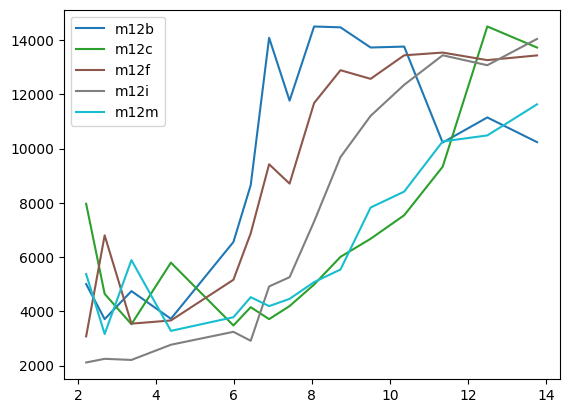

In [4]:
for j, sim in enumerate(sim_lst):
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    snap_lim = snap_lim_lst[j]
    # time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].values
    time_lst = pub_snaps[(pub_snaps["index"] >= snap_min) & (pub_snaps["index"] <= snap_max)][
        "time_Gyr"
    ].values

    it_full_avg = []
    it_full_avg_log = []
    for it_id in proc_data.keys():
        snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
        snp_dat_600_msk = snp_dat_600["group_id"][()] == group_id
        gcid_surv_lst = snp_dat_600["gc_id"][snp_dat_600_msk]

        it_med = []
        it_med_log = []
        # for snap_id in proc_data[it_id]["snapshots"].keys():
        for i, snap_id in enumerate(proc_data[it_id]["snapshots"].keys()):
            snap = int(snap_id[4:])
            # if snap < snap_lim:
            if (snap < snap_min) | (snap_max < snap):
                continue

            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            snp_msk = np.isin(snp_dat["gc_id"][()], gcid_surv_lst)
            if np.sum(snp_msk) == 0:
                it_med.append(np.nan)
                it_med_log.append(np.nan)
                continue

            it_med.append(np.mean(snp_dat["tideig_1"][snp_msk] - snp_dat["tideig_3"][snp_msk]))
            it_med_log.append(np.mean(np.log10(snp_dat["tideig_1"][snp_msk] - snp_dat["tideig_3"][snp_msk])))
            # plt.scatter([time_lst[i]] * len(snp_dat["r"][snp_msk]), snp_dat["ek"][snp_msk])
        it_full_avg.append(it_med)
        it_full_avg_log.append(it_med_log)

    avg_tidem = np.nanmean(it_full_avg, axis=0)
    avg_tidem_log = np.nanmean(it_full_avg_log, axis=0)
    plt.plot(time_lst, avg_tidem, c=colors[j], label=sim)

    sim_dict[sim]["avg_tidem"] = avg_tidem
    sim_dict[sim]["avg_tidem_log"] = avg_tidem_log

plt.legend()

In [5]:
def get_density(part, snap, halt, ptype="star", rlim=3, temp_lim=None):
    volume = (4 * np.pi / 3) * (rlim**3)

    main_halo = sim_codes[sim]["halo"]
    halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
    halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]

    part_dist = ut.coordinate.get_distances(
        part[ptype]["position"],
        halt["position"][halo_tidx],
        part.info["box.length"],
        part.snapshot["scalefactor"],
        True,
    )  # [kpc physical]

    part_msk = part_dist <= rlim

    if temp_lim is not None:
        temp_msk = np.log10(part[ptype]["temperature"]) <= temp_lim
        part_mass = np.sum(part[ptype]["mass"][part_msk & temp_msk])
    else:
        part_mass = np.sum(part[ptype]["mass"][part_msk])

    part_dens = part_mass / volume

    return part_dens

In [6]:
def get_sfr(part, snap, halt, rlim=3):
    main_halo = sim_codes[sim]["halo"]
    halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
    halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]

    gas_dist = ut.coordinate.get_distances(
        part["gas"]["position"],
        halt["position"][halo_tidx],
        part.info["box.length"],
        part.snapshot["scalefactor"],
        True,
    )  # [kpc physical]

    gas_msk = gas_dist <= rlim
    sfr = np.nansum(part["gas"]["sfr"][gas_msk])  # instantaneous star formation rate [M_sun / yr]

    star_dist = ut.coordinate.get_distances(
        part["star"]["position"],
        halt["position"][halo_tidx],
        part.info["box.length"],
        part.snapshot["scalefactor"],
        True,
    )  # [kpc physical]

    star_msk = star_dist <= rlim
    star_mass = np.sum(part["star"]["mass"][star_msk])
    ssfr = sfr / star_mass

    return sfr, ssfr

In [7]:
for j, sim in enumerate(sim_lst):
    fire_dir = sim_dir + sim + "/" + sim + "_res7100"
    halt = gc_utils.get_halo_tree(sim, sim_dir)

    # snap_lim = snap_lim_lst[j]
    # snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].values
    snap_lst = pub_snaps[(pub_snaps["index"] >= 120) & (pub_snaps["index"] <= 590)]["index"].values

    star_dens_lst = []
    gas_dens_lst = []
    cold_gas_dens_lst = []
    sfr_lst = []
    ssfr_lst = []
    for snap in snap_lst:
        # part = gc_utils.open_snapshot(snap, fire_dir, species=["star", "gas"])
        part = gc_utils.open_snapshot(snap, fire_dir, species=["star"])
        star_dens_lst.append(get_density(part, snap, halt, ptype="star", rlim=3))
        # gas_dens_lst.append(get_density(part, snap, halt, ptype="gas", rlim=3))
        # cold_gas_dens_lst.append(get_density(part, snap, halt, ptype="gas", rlim=3, temp_lim=4.5))

        # sfr, ssfr = get_sfr(part, snap, halt, rlim=3)
        # sfr_lst.append(sfr)
        # ssfr_lst.append(ssfr)

    sim_dict[sim]["star_dens"] = np.array(star_dens_lst)
    sim_dict[sim]["gas_dens"] = np.array(gas_dens_lst)
    sim_dict[sim]["cold_gas_dens"] = np.array(cold_gas_dens_lst)
    sim_dict[sim]["sfr"] = np.array(sfr_lst)
    sim_dict[sim]["ssfr"] = np.array(ssfr_lst)

Retrieving Snapshot 590..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:16<00:00, 16.81s/it]


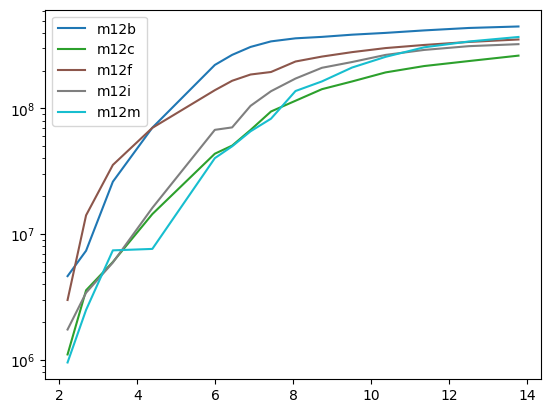

In [8]:
for j, sim in enumerate(sim_lst):
    snap_lim = snap_lim_lst[j]
    # time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].values
    time_lst = pub_snaps[(pub_snaps["index"] >= 120) & (pub_snaps["index"] <= 590)]["time_Gyr"].values
    plt.plot(time_lst, sim_dict[sim]["star_dens"], c=colors[j], label=sim)

plt.legend()
plt.yscale("log")

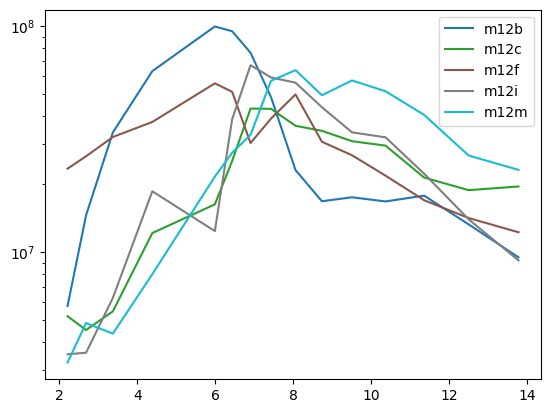

In [9]:
for j, sim in enumerate(sim_lst):
    snap_lim = snap_lim_lst[j]
    # time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].values
    time_lst = pub_snaps[(pub_snaps["index"] >= 120) & (pub_snaps["index"] <= 590)]["time_Gyr"].values
    val = np.gradient(sim_dict[sim]["star_dens"], time_lst)

    plt.plot(time_lst, val, c=colors[j], label=sim)

plt.legend()
plt.yscale("log")

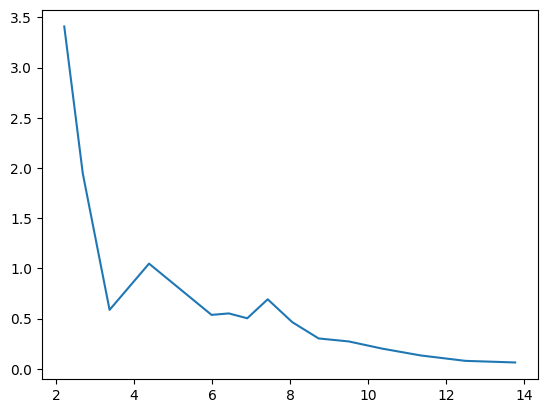

In [10]:
grad = np.gradient(sim_dict[sim]["star_dens"], time_lst)

plt.plot(time_lst, grad / sim_dict[sim]["star_dens"])

In [11]:
time_lst

array([ 2.21035546,  2.68527705,  3.37228352,  4.38467705,  5.98814366,
        6.43194407,  6.90376726,  7.42876967,  8.0576176 ,  8.73476537,
        9.50745578, 10.36813558, 11.35578917, 12.50060116, 13.77655646])

In [12]:
snap_lst  # 356

array([120, 142, 172, 214, 277, 294, 312, 332, 356, 382, 412, 446, 486,
       534, 590])

In [13]:
grad / sim_dict[sim]["star_dens"]

array([3.41016964, 1.94600183, 0.58659615, 1.04740895, 0.53672083,
       0.5512437 , 0.50284962, 0.69203573, 0.46467311, 0.3018675 ,
       0.27215121, 0.20030997, 0.13231093, 0.0785749 , 0.06249661])

# Correlations

In [14]:
sim = "m12f"
snap_lim = 46  # 102 for m12m else 46
imin = 0  # 1 for m12m else 7
imax = 15

# time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].values
time_lst = pub_snaps[(pub_snaps["index"] >= 120) & (pub_snaps["index"] <= 590)]["time_Gyr"].values

time_lst[imin:imax], len(time_lst[imin:imax])

(array([ 2.21035546,  2.68527705,  3.37228352,  4.38467705,  5.98814366,
         6.43194407,  6.90376726,  7.42876967,  8.0576176 ,  8.73476537,
         9.50745578, 10.36813558, 11.35578917, 12.50060116, 13.77655646]),
 15)

In [15]:
# stats.pearsonr(sim_dict[sim]["avg_tidem"][imin:imax], sim_dict[sim]["star_dens"][imin:imax])
stats.pearsonr(sim_dict[sim]["avg_et_norm"][imin:imax], sim_dict[sim]["avg_tidem"][imin:imax])

PearsonRResult(statistic=0.703960448341826, pvalue=0.0033987931819881483)

In [16]:
stats.spearmanr(sim_dict[sim]["avg_et_norm"][imin:imax], sim_dict[sim]["avg_tidem"][imin:imax])

SignificanceResult(statistic=0.48214285714285704, pvalue=0.06874953772064366)

In [17]:
go = []

for sim in sim_lst:
    tmax = np.max(sim_dict[sim]["avg_tidem"])
    tmin = np.min(sim_dict[sim]["avg_tidem"])
    tavg = np.mean(sim_dict[sim]["avg_tidem"])

    go.append(tavg)

go

[9756.794448346905,
 6685.320533252232,
 9207.345323349811,
 7121.801491692511,
 6263.113641141867]

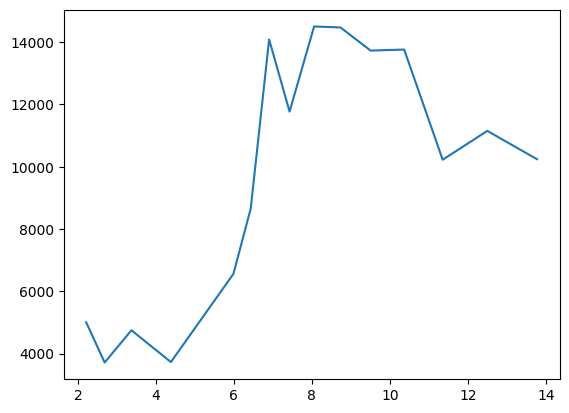

In [18]:
sim = "m12b"

plt.plot(time_lst, sim_dict[sim]["avg_tidem"])

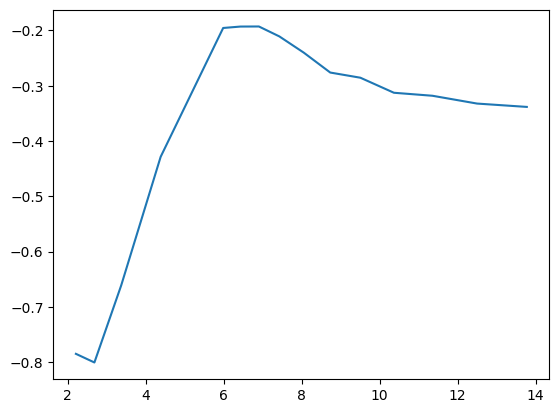

In [19]:
plt.plot(time_lst, sim_dict[sim]["avg_et_norm"])